# Ligand binding MSM: trypsin + benzamidine

**You will learn:** how to take unbiased binding trajectories of a small drug-like ligand and a protein receptor and build a Markov-state model that gives you the bound macrostate, the binding pathways, the binding affinity (K<sub>d</sub>), and on / off rates.

**Prerequisites:**
- HTMD installed.
- `wget` available on `$PATH`.
- ~5 GB of disk for the trajectory download.

## The system

Trypsin is a serine protease; benzamidine is a small competitive inhibitor that docks into the S1 specificity pocket. The dataset contains short unbiased trajectories started from many random ligand poses around the protein - some find the binding pocket, most don't. Aggregate sampling is ≈ 17 µs across 852 trajectories.

The point of this analysis is to reconstruct the binding free-energy surface and rates *without ever steering the ligand* - just by counting transitions between metastable states discovered by clustering the trajectories.

## The flow

Same MSM pipeline as the {doc}`villin folding tutorial <villin-folding>` - the only thing that changes is **the projection**: for a binding problem the slow coordinate is the protein-ligand distance pattern, not the protein's own contact map.

1. Download + simlist.
2. Project with {py:class}`~moleculekit.projections.metricdistance.MetricDistance` between protein Cα atoms and ligand heavy atoms.
3. TICA to find the slow binding modes.
4. Cluster, build MSM, lump into macrostates.
5. Read out the FES, MFPTs, k<sub>on</sub> / k<sub>off</sub>, and K<sub>d</sub>.

## Setup

In [1]:
import os
from glob import glob
from pathlib import Path
from htmd.ui import (
    simlist, simmerge,
    Metric, MetricDistance,
    TICA, Model, Kinetics,
)
from sklearn.cluster import MiniBatchKMeans

2026-06-02 18:40:37,204 - rdkit - INFO - Enabling RDKit 2026.03.2 jupyter extensions



Please cite HTMD: Doerr et al.(2016)JCTC,12,1845. https://dx.doi.org/10.1021/acs.jctc.6b00049
HTMD Documentation at: https://software.acellera.com/htmd/

You are on the latest HTMD version (2.8.5.dev17+gf26491d44.d20260602).



## Step 1 - Build the simlist

The trajectory bundle ships on Figshare ([HTMD tutorial data, DOI 10.6084/m9.figshare.32541291](https://doi.org/10.6084/m9.figshare.32541291)) as [ligand_binding_datasets.zip](https://ndownloader.figshare.com/files/65180823) (~3 GB).

The dataset is split into several "epochs" (adaptive-sampling rounds). {py:func}`~htmd.simlist.simlist` builds one per-epoch list (duplicate folder basenames within a single call would raise), and {py:func}`~htmd.simlist.simmerge` stitches them into a combined list and renumbers the per-sim `simid` indices to be sequential across the merged whole:

In [2]:
DATASETS = Path(os.environ["HTMD_TUTORIAL_DATASETS"]) / "ligand_binding_datasets"
topology = str(DATASETS / "1" / "filtered")  # any epoch works - all share the same topology
sims = []
for epoch in sorted(DATASETS.glob("*/")):
    trajs = glob(os.path.join(epoch, "filtered", "*", ""))
    sims = simmerge(sims, simlist(trajs, topology))
len(sims)

852

## Step 2 - Project: protein-ligand contacts

For binding, the relevant coordinate is "which protein residue is the ligand currently in contact with". {py:class}`~moleculekit.projections.metricdistance.MetricDistance` computes the distance matrix between two atom selections; with `metric="contacts"` you get a binary contact map per frame between every protein Cα and every ligand heavy atom (1 if the distance is below the `threshold`, 0 otherwise - default `threshold=8` Å).

In [3]:
metr = Metric(sims)
metr.set(MetricDistance(
    "protein and name CA",
    "resname MOL and noh",
    periodic="selections",
    metric="contacts",
))
data = metr.project()
data.fstep = 0.1

htmd.projections.metric - INFO - Frame step 0.001ns was read from the trajectories. If it looks wrong, redefine it by manually setting the MetricData.fstep property.


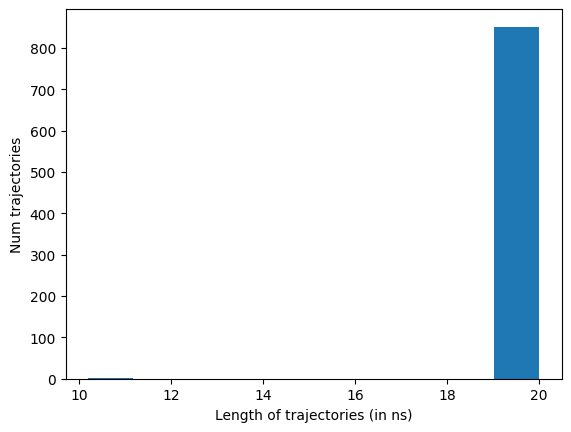

htmd.metricdata - INFO - Dropped 2 trajectories from 852 resulting in 850


array([496, 562])

In [4]:
data.plotTrajSizes()
data.dropTraj()

`periodic="selections"` makes the distance calculation use **minimum-image** distances between the two atom selections, so a ligand that has wrapped through PBC gets compared to the *closest* protein image - the original coordinates aren't modified, only the distances are computed correctly across the box.

## Step 3 - TICA

In [5]:
tica = TICA(data, 2, units="ns")
dataTica = tica.project(3)

## Step 4 - Cluster + MSM

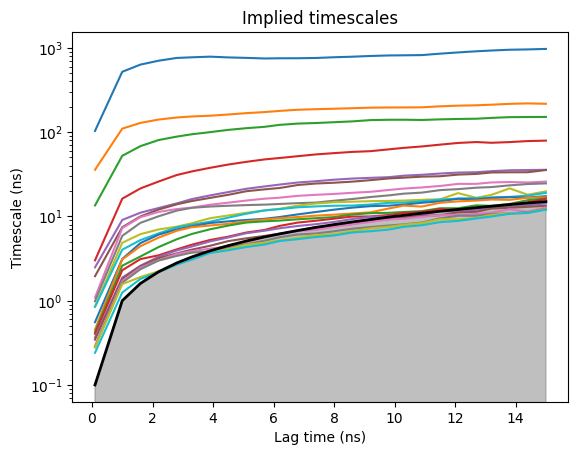

In [6]:
dataBoot = dataTica.bootstrap(0.8)
dataBoot.cluster(MiniBatchKMeans(n_clusters=1000))

model = Model(dataBoot)
model.plotTimescales(maxlag=15, units="ns")

The slow timescale for binding is much shorter than folding (ligand diffusion happens on the ns-100ns scale, not µs). Read the lag off the ITS plot - usually around 5 ns for this system.

In [7]:
model.markovModel(5, 5, units="ns")

htmd.model - INFO - 100.0% of the data was used


htmd.model - INFO - Number of trajectories that visited each macrostate:


htmd.model - INFO - [153 105 376 127 220]


Five macrostates: bound + a few "encountered but not docked" intermediates + the bulk solution.

## Step 5 - Free-energy surface

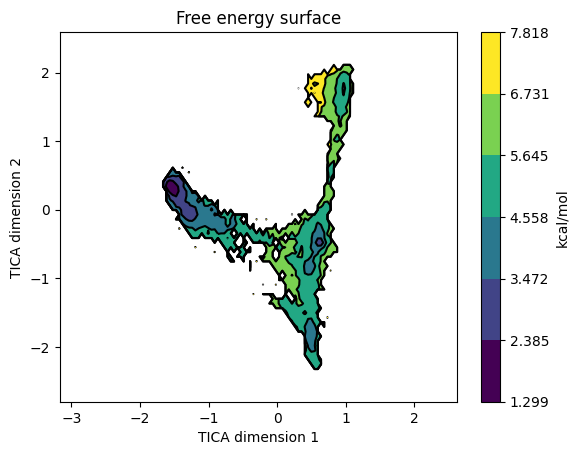

In [8]:
model.plotFES(0, 1, temperature=298)

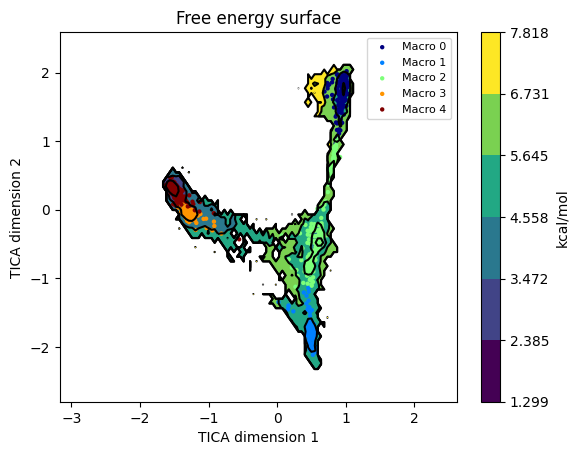

In [9]:
model.plotFES(0, 1, temperature=298, states=True)

The bound state usually appears as a deep basin in one corner of TIC1 / TIC2; the bulk-solution state spreads across most of the projected area; the intermediates are shallow basins between them.

To overlay representative protein + ligand snapshots from each macrostate, run `model.viewStates(ligand="resname MOL and noh")` from an interactive session - it launches VMD. (Omitted here because it needs a display.)

## Step 6 - Kinetics + K<sub>d</sub>

In [10]:
kin = Kinetics(model, temperature=298, concentration=0.0037)

htmd.kinetics - INFO - Detecting source state...


htmd.kinetics - INFO - Guessing the source state as the state with minimum contacts.


htmd.kinetics - INFO - Source macro = 2


htmd.kinetics - INFO - Detecting sink state...


htmd.kinetics - INFO - Sink macro = 4


`concentration=0.0037` mol/L is the effective bulk ligand concentration in this simulation box (one ligand in the periodic box of this volume). {py:class}`~htmd.kinetics.Kinetics` uses it to convert the simulated rates into experimental units - **k<sub>on</sub>** (M⁻¹ s⁻¹), **k<sub>off</sub>** (s⁻¹), and **K<sub>d</sub> = k<sub>off</sub> / k<sub>on</sub>**.

In [11]:
r = kin.getRates()
print(r)

htmd.kinetics - INFO - Calculating rates between source: [np.int64(2)] and sink: [np.int64(4)] states.


htmd.kinetics - INFO - Concentration correction of -3.32 kcal/mol.


mfpton = 7.88E+02 (ns)
mfptoff = 6.80E+03 (ns)
kon = 3.43E+08 (1/M 1/s)
koff = 1.47E+05 (1/s)
koff/kon = 4.29E-04 (M)
kdeq = 3.58E-04 (M)
g0eq = -4.70 (kcal/M)



{py:meth}`~htmd.kinetics.Kinetics.getRates` returns a single `Rates` object for the auto-detected source → sink pair (bulk → bound here). It carries the MFPT, rate, and k<sub>on</sub> / k<sub>off</sub> / K<sub>d</sub>. Match against the experimental K<sub>d</sub> to validate the model. Use `kin.plotRates()` (below) for an all-pairs visualisation, or call `getRates(source=..., sink=...)` explicitly for other pairings.

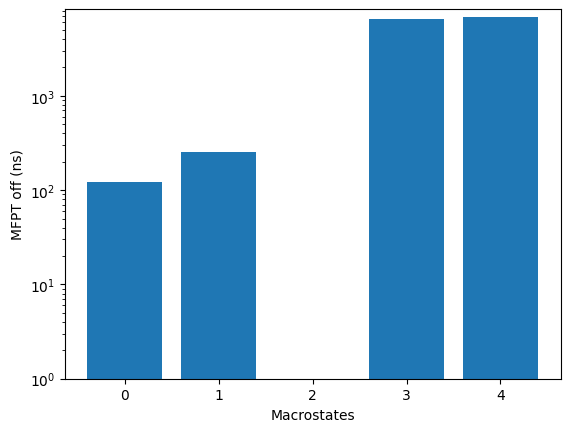

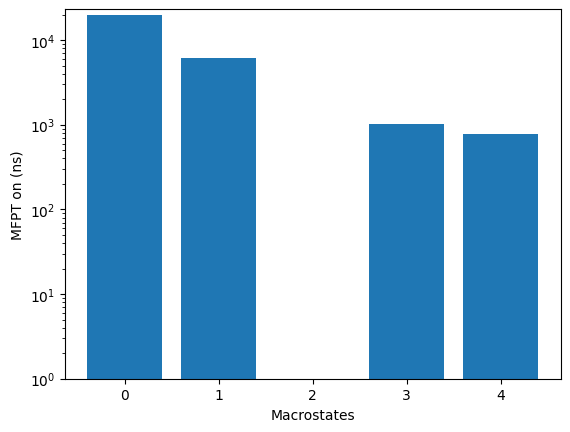

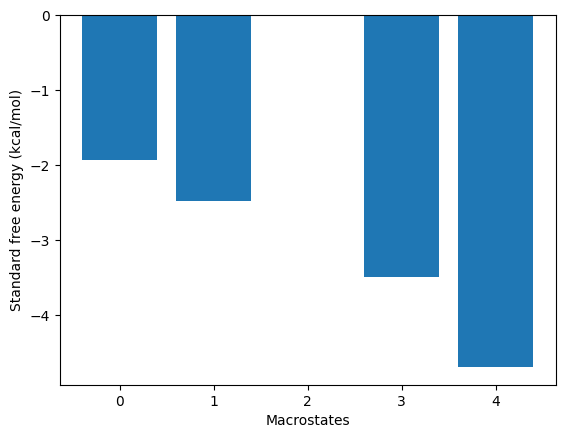

In [12]:
kin.plotRates()

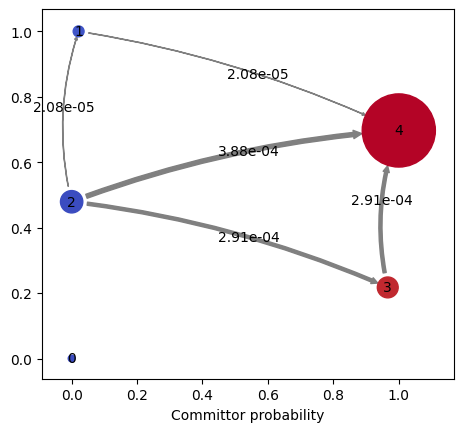

Path flux		%path	%of total	path
0.00038753881932143707	55.4%	55.4%		[2 4]
0.00029093136484922627	41.6%	97.0%		[2 3 4]
2.0777315285460142e-05	3.0%	100.0%		[2 1 4]


In [13]:
kin.plotFluxPathways()

The flux pathways show which intermediates the ligand visits on the way from solution to the bound pocket - useful for understanding the binding mechanism (e.g. is there a kinetic trap on the surface? Does the ligand approach from a specific direction?).

## Parameters that matter

| Knob | Effect |
| --- | --- |
| `MetricDistance(sel1, sel2, ... metric="contacts")` | Coarse but the right default for binding - thresholding collapses the huge unbound bulk region into a single "no contacts" state. `metric="distances"` would spread that bulk across thousands of useless microstates and overwhelm the bound-state resolution. |
| `threshold` on `MetricDistance` | Default 8 Å. Lower (e.g. 5 Å) tightens what counts as "in contact" and emphasises tighter poses; higher dilates the bound basin. |
| `concentration` on `Kinetics` | Critical for **k<sub>on</sub>** and **K<sub>d</sub>**. Compute it as (n<sub>ligands</sub> / n<sub>waters</sub>) · 55.4 mol/L - the water count tracks the real bulk volume more accurately than the box volume, which over-counts because it includes the protein's excluded volume. |
| `periodic="selections"` on the projection | **Essential** when the ligand wraps through the box during the trajectory. Skipping it produces nonsense contacts at PBC crossings. |
| `model.markovModel(lag, macronum)` `macronum` | More macrostates → more pathway resolution but harder to interpret. 4-6 is typical for binding. |

## Gotchas

- **The bulk state is huge and unstructured.** With `metric="contacts"` the unbound bulk collapses to essentially a single microstate (all-zero contact vector), which is exactly what you want for binding analysis. Don't over-interpret intermediate basins that have very small populations - they may be undersampled.
- **Bound-state validation.** Before trusting K<sub>d</sub>, open `viewStates(ligand=...)` and confirm the bound macrostate actually puts the ligand in the experimental pocket. If it's binding to the wrong site, your model is sampling a metastable mis-pose.
- **Symmetric ligands.** Benzamidine is roughly C₂v-symmetric; for ligands without that symmetry, atom-pair distances can flip when the ligand rotates 180°. Either symmetrise the contact features manually or accept that the model will distinguish the two flipped orientations as separate states.

## See also

- {doc}`MSM workflow explanation <../../explanation/msm-workflow>` - what's happening under the hood.
- {doc}`Protein folding MSM <villin-folding>` - same pipeline, different projection.
- {doc}`Adaptive sampling <../adaptive/index>` - how the binding trajectory set was generated (random starting poses + adaptive sampling targeting under-explored regions).